In [12]:
import numpy as np
import xarray as xr
import rioxarray as rxr
from odc.geo.xr import ODCExtensionDa
import matplotlib.pyplot as plt

In [3]:
modis = xr.open_zarr(
    "/scicore/home/meiera/schulz0022/projects/growth-and-temperature/data_nobackup/glass/LST/MODIS/Daily/1KM/processed/stage_2/modis_timeseries_reprojected.zarr",
    consolidated=False
    )

In [18]:
modis_subset = modis.isel(time=-1, latitude=slice(10_000, 11_000), longitude=slice(15_000, 16_000)).compute()
modis_subset

<xarray.Dataset> Size: 68MB
Dimensions:      (band: 1, latitude: 1000, longitude: 1000)
Coordinates:
  * longitude    (longitude) float64 8kB -117.5 -117.5 -117.5 ... -113.3 -113.3
  * latitude     (latitude) float64 8kB 33.33 33.33 33.33 ... 29.18 29.18 29.17
  * band         (band) int64 8B 1
    time         datetime64[ns] 8B 2020-12-31
Data variables:
    median       (band, latitude, longitude) float64 8MB 294.1 294.1 ... 302.1
    max          (band, latitude, longitude) float64 8MB 306.0 306.0 ... 309.9
    spatial_ref  int64 8B 0
    std          (band, latitude, longitude) float64 8MB 6.81 6.81 ... 7.02 7.02
    rollmin3     (band, latitude, longitude) float64 8MB 283.0 283.0 ... 289.1
    min          (band, latitude, longitude) float64 8MB 281.7 281.7 ... 286.6
    gt30C        (band, latitude, longitude) float32 4MB 21.0 21.0 ... 78.0 78.0
    lt0C         (band, latitude, longitude) float32 4MB nan nan nan ... nan nan
    mean         (band, latitude, longitude) float64 8MB 293.4 293.4 ... 299.7
    rollmax3     (band, latitude, longitude) float64 8MB 304.9 304.9 ... 308.5
    valid_count  (band, latitude, longitude) float32 4MB 365.0 365.0 ... 175.0

In [ ]:
median, mean, rollmax3

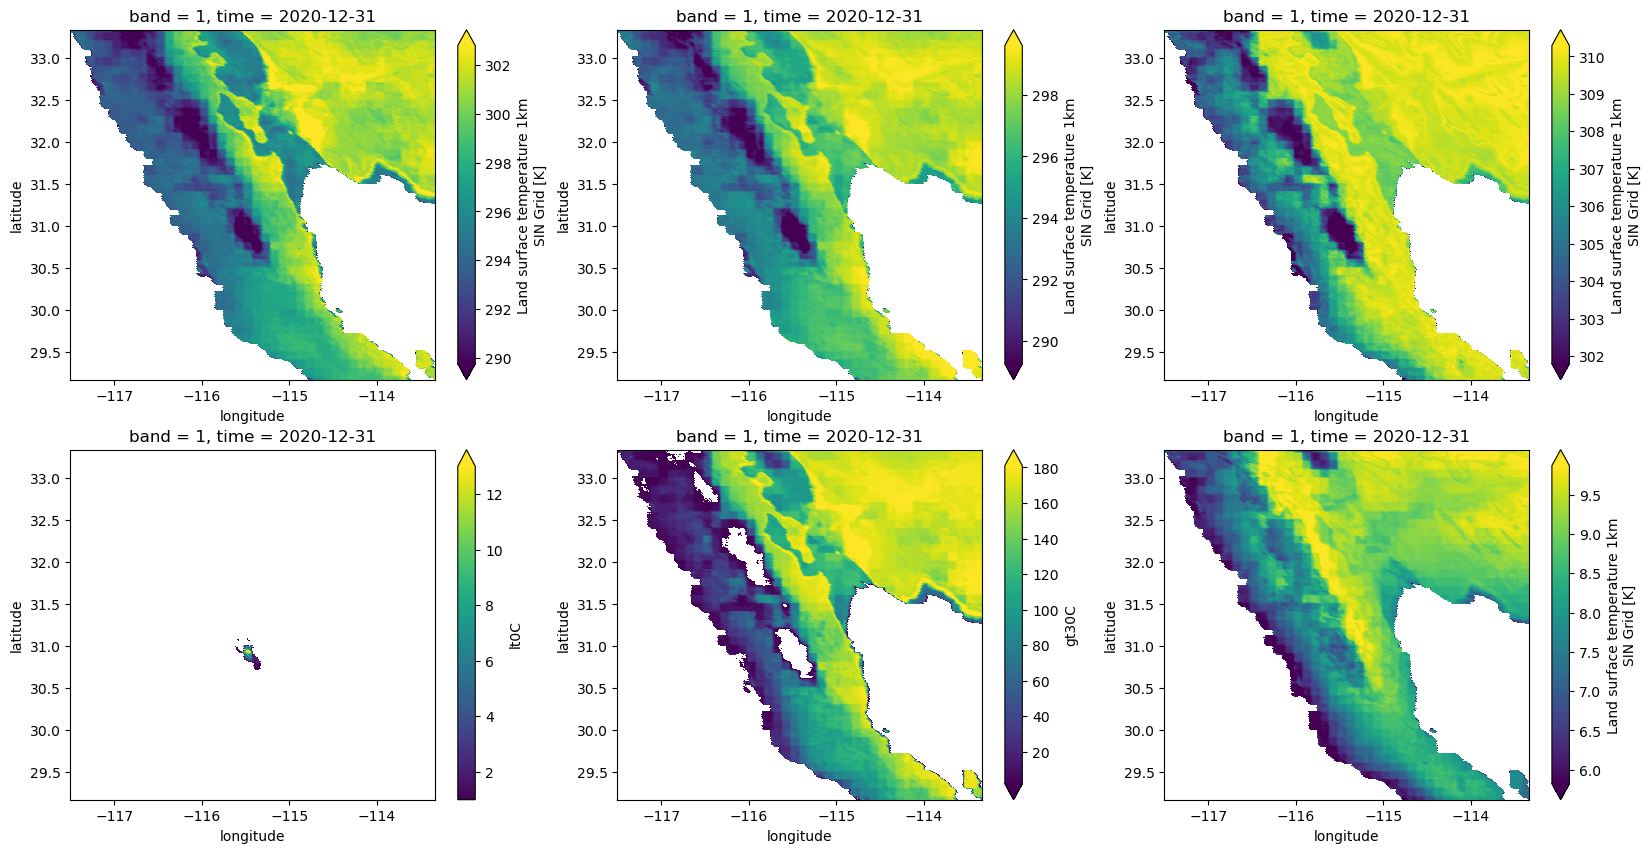

In [ ]:
fig, ax = plt.subplots(2,4, figsize=(50,10))

modis_subset["median"].squeeze().plot.imshow(ax=ax[0,0], robust=True)

modis_subset["mean"].squeeze().plot.imshow(ax=ax[0,1], robust=True)

modis_subset["rollmax3"].squeeze().plot.imshow(ax=ax[0,2], robust=True)

modis_subset["lt0C"].squeeze().plot.imshow(ax=ax[1,0], robust=True)

modis_subset["gt30C"].squeeze().plot.imshow(ax=ax[1,1], robust=True)

modis_subset["std"].squeeze().plot.imshow(ax=ax[1,2], robust=True)

---

In [1]:
import duckdb

In [2]:
conn = duckdb.connect("/scicore/home/meiera/schulz0022/projects/growth-and-temperature/scratch_nobackup/tmp.db")

In [4]:
conn.sql("""
    SELECT *
    FROM read_parquet("/scicore/home/meiera/schulz0022/projects/growth-and-temperature/data_nobackup/assembled/1km.parquet/**/*.parquet")
""")

┌───────┬───────┬────────────────────┬────────────────────┬────────────────────┬─────────────┬──────────┬────────────────────┬────────────┬────────────────┬─────────────┬──────────────┬──────────┬──────────────┬──────────────┬────────────┬────────────┬─────────┬─────────────┬────────┬────────┬───────┬───────┬───────┬────────┬───────┬───────┐
│ index │ year  │    modis_median    │     modis_mean     │   modis_rollmax3   │ modis_gt30C │ pixel_id │    avhrr_median    │ avhrr_mean │ avhrr_rollmax3 │ avhrr_gt30C │ viirs_annual │ ntl_harm │ adm1_reg_fav │ adm2_reg_fav │ nb_diamond │ nb_mines_a │ country │ subdivision │ HDI_ME │ HDI_HI │ WB_LM │ WB_HI │ WB_UM │ HDI_VH │  ix   │  iy   │
│ int64 │ int16 │       double       │       double       │       double       │    float    │  uint64  │       double       │   double   │     double     │   double    │    double    │  double  │    float     │    float     │   float    │   float    │  float  │    float    │ float  │ float  │ float │ float │ f

In [12]:
conn.sql(
    """
        SELECT * REPLACE (
            CASE WHEN modis_gt30C IS NULL AND modis_median IS NOT NULL THEN 0 ELSE modis_gt30C END AS modis_gt30C,
            CASE WHEN avhrr_gt30C IS NULL AND avhrr_median IS NOT NULL THEN 0 ELSE avhrr_gt30C END AS avhrr_gt30C
        )
        FROM read_parquet("/scicore/home/meiera/schulz0022/projects/growth-and-temperature/data_nobackup/assembled/_1km.parquet/**/*.parquet")
    """
)

┌───────┬─────────────┬──────────────┬────────────┬────────────────┬─────────────┬──────────────┬────────────┬────────────────┬─────────────┬──────────────┬──────────┬─────────┬────────────┬────────────┬─────────┬─────────────┬───────┬────────┬───────┬───────┬────────┬────────┬──────────┬───────┬───────┐
│ year  │ spatial_ref │ modis_median │ modis_mean │ modis_rollmax3 │ modis_gt30C │ avhrr_median │ avhrr_mean │ avhrr_rollmax3 │ avhrr_gt30C │ viirs_annual │ ntl_harm │ reg_fav │ nb_diamond │ nb_mines_a │ country │ subdivision │ WB_LM │ HDI_ME │ WB_UM │ WB_HI │ HDI_HI │ HDI_VH │ pixel_id │  ix   │  iy   │
│ int16 │    int32    │    double    │   double   │     double     │    float    │    double    │   double   │     double     │    float    │    double    │  double  │  float  │   float    │   float    │  float  │    float    │ float │ float  │ float │ float │ float  │ float  │  uint64  │ int64 │ int64 │
├───────┼─────────────┼──────────────┼────────────┼────────────────┼─────────────┼

In [14]:
conn.sql("""
    COPY (
        SELECT * REPLACE (
            CASE WHEN modis_gt30C IS NULL AND modis_median IS NOT NULL THEN 0 ELSE modis_gt30C END AS modis_gt30C,
            CASE WHEN avhrr_gt30C IS NULL AND avhrr_median IS NOT NULL THEN 0 ELSE avhrr_gt30C END AS avhrr_gt30C
        )
        FROM read_parquet("/scicore/home/meiera/schulz0022/projects/growth-and-temperature/data_nobackup/assembled/_1km.parquet/**/*.parquet")
    )
    TO "/scicore/home/meiera/schulz0022/projects/growth-and-temperature/data_nobackup/assembled/__1km.parquet"
    (FORMAT PARQUET);
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

: 

: 

: 